**Feature Relationships**

**Correlation Matrix:**

Correlation measures the strength and direction of the relationship between two numerical variables.

The most commonly used measure is Pearson correlation.

Its value ranges from:

-1  ─────────  0  ─────────  +1



In [1]:
import pandas as pd

data = {
    "Hours_Studied": [1, 2, 3, 4, 5],
    "Exam_Score": [40, 50, 60, 70, 80],
    "Sleep_Hours": [8, 7, 6, 6, 5]
}

df = pd.DataFrame(data)

correlation_matrix = df.corr()

print(correlation_matrix)

               Hours_Studied  Exam_Score  Sleep_Hours
Hours_Studied       1.000000    1.000000    -0.970725
Exam_Score          1.000000    1.000000    -0.970725
Sleep_Hours        -0.970725   -0.970725     1.000000


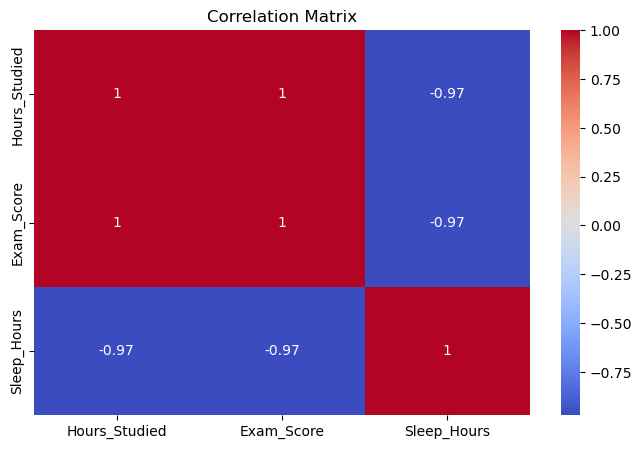

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

**Multicollinearity**

Multicollinearity occurs when two or more independent/input features are highly related to each other.

In simple words:

Multiple features are providing very similar information.

Example

Suppose we have:

House Area in square feet
House Area in square meters

These two features contain almost the same information.

Therefore:

Area_sqft ↔ Area_sqm

will have very high correlation.

**Business Example:**

Suppose we predict salary using:

Years of Experience
Months of Experience
Age

There may be strong relationships among these variables.

Months of Experience ≈ Years of Experience × 12

Including both can introduce multicollinearity.

**Variance Inflation Factor (VIF):**

VIF measures how much the variance of an estimated regression coefficient is inflated because of relationships between predictors.

Suppose we have:

Age
Experience
Salary

To calculate VIF for Experience, we temporarily treat:  Experience

as the target and try to predict it using:  Age
Salary

If the other features can predict Experience very well, then Experience contains information that overlaps heavily with the other predictors.

R² → high

In [3]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = {
    "Age": [25, 30, 35, 40, 45, 50],
    "Experience": [2, 5, 8, 12, 15, 20],
    "Salary": [30, 40, 50, 65, 75, 90]
}

df = pd.DataFrame(data)

X = df[
    ["Age", "Experience", "Salary"]
]

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

      Feature          VIF
0         Age  3279.957265
1  Experience  1200.905983
2      Salary  8218.410256


**Feature Importance:**

Feature importance tells us how useful each feature is to a particular machine-learning model's predictions.

For example, in a house-price model:

Area              → 45%
Location          → 30%
Bedrooms          → 15%
Age                → 10%

This would suggest that Area contributes strongly to the model according to the selected importance method.

**1. Tree-based feature importance:**

Algorithms such as:

Decision Tree
Random Forest
Gradient Boosting

can calculate feature importance based on how features contribute to reducing impurity/loss across the trees.

In [4]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X = pd.DataFrame({
    "Area": [1000, 1200, 1500, 1800, 2000],
    "Bedrooms": [2, 2, 3, 3, 4],
    "Age": [10, 8, 5, 3, 1]
})

y = [50, 60, 75, 90, 110]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

print(importance.sort_values(ascending=False))

Area        0.389441
Bedrooms    0.308991
Age         0.301569
dtype: float64


**2.Permutation Importance:**

Permutation importance asks:

What happens to model performance if I randomly shuffle one feature?

If shuffling a feature causes a large performance decrease, that feature was important to the model's predictions.

This can be more informative than relying only on tree impurity-based importance.

In [6]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X,
    y,
    random_state=42
)

importance = pd.Series(
    result.importances_mean,
    index=X.columns
)

print(importance.sort_values(ascending=False))

Area        0.418057
Age         0.272332
Bedrooms    0.244102
dtype: float64


**3.Coefficients:**

For models such as Linear Regression or Logistic Regression, coefficients can provide information about the relationship between predictors and the model output.

In [ ]:
Feature       Coefficient
-------------------------
Age              -2.1
Income            4.5
Experience        3.2

**Feature Selection Basics:**

Feature selection means choosing the most useful input features for a machine-learning model and removing features that are:

Irrelevant

Redundant

Noisy

Uninformative

Potentially harmful to generalization

**Feature Selection Methods:**

A. Filter Methods

  Filter methods select features based on statistical properties before training the final model.

B  Wrapper Methods

Wrapper methods evaluate subsets of features by repeatedly training a model.

One popular technique is:

RFE – Recursive Feature Elimination

C  Embedded Methods

Feature selection happens during model training.

Examples:

Lasso Regression

Decision Trees

Random Forest

Gradient Boosting

In [8]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()

selector = RFE(
    estimator=model,
    n_features_to_select=2
)

selector.fit(X, y)

print(selector.support_)
print(selector.ranking_)

[False  True  True]
[2 1 1]
